# 0 GOAL: perform clustering analysis on an example dataset
##  We compare different models. 

# 1. Import the *ds1.csv* dataset


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ds1.csv')
df

,x1,x2,class
0,10.500000,9.000000,1
1,10.567170,9.268445,1
2,8.275320,11.382210,1
3,8.227458,11.377640,1
4,8.179511,11.372110,1
...,...,...,...
1995,35.081000,30.135357,4
1996,35.186100,29.350480,4
1997,35.204200,29.514780,4
1998,35.921200,27.968540,4


# 2. Perform an **exploratory analysis**


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      2000 non-null   float64
 1   x2      2000 non-null   float64
 2   class   2000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 47.0 KB


- there are 2000 instances
- the ground truth labels are available
- each instance is represented in a bidimensional space. We can visually inspect the dataset.

In [5]:
df.describe()

,x1,x2,class
count,2000.000000,2000.000000,2000.000000
mean,16.999467,16.994953,2.500000
std,9.091342,9.111186,1.118314
min,2.511150,3.308880,1.000000
25%,9.000000,9.000000,1.750000
50%,15.302310,14.690090,2.500000
75%,24.525165,24.891540,3.250000
max,36.702800,35.783340,4.000000


<AxesSubplot:xlabel='x1', ylabel='x2'>

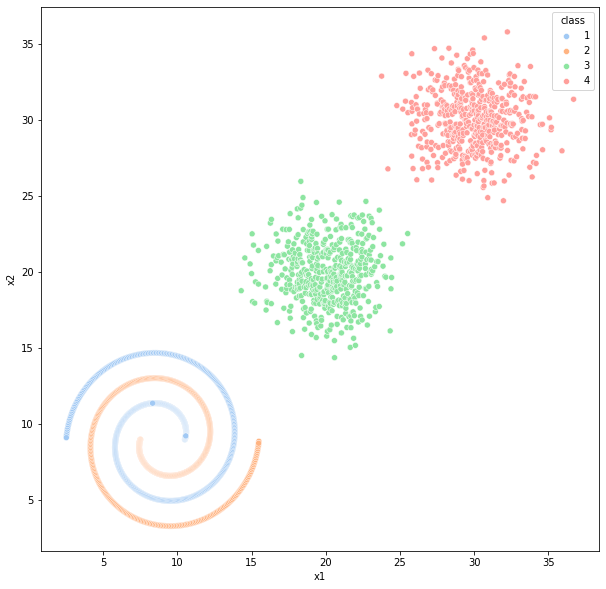

In [6]:
plt.figure(figsize = (10, 10))
sns.scatterplot(data = df, x = 'x1',y = 'x2', hue = 'class', palette = 'pastel')

- Scatter plot of the dataset. Color representation reflects the ground truth partition.
- Observations:
    - two clusters seems to originate from gaussian distributions (centered in (20,20) and (30,30)) (spherical clusters)
    - two clusters results in two nested spirals (non spherical)

# 3. Carry out a **clustering analysis**:
- Choose a suitable clustering algorithm and motivate your choice.
- Discuss the clustering results in terms of one or more external metrics.
- Evaluate the sensitivity of the clustering algorithm with respect to its most influential input parameter or parameters
- For each clustering evaluation, display the clustering result as a scatter plot.


I select DBSCAN as a suitable clustering algorithms as objects in clusters seem to be densely connected.

A partitioning based method (e.g., K-Means) would fail in capturing non spherical clusters.

Hierarchical clustering may also work well.

# 3.1 DBSCAN

In [7]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score

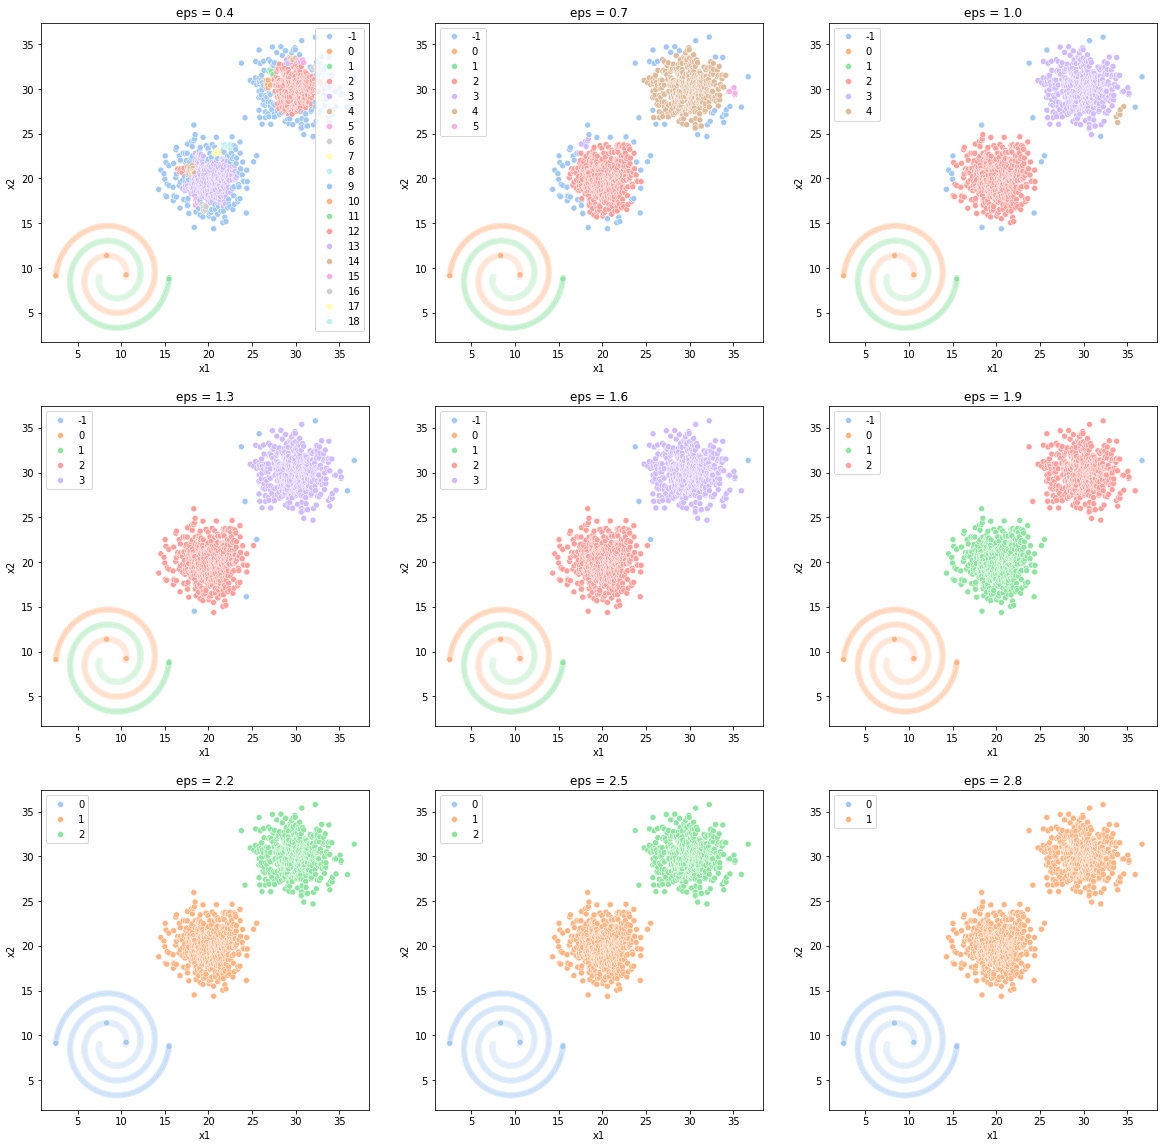

In [8]:
f, axes = plt.subplots(3, 3, figsize=(20, 20))
i = 0
ari_list = []
for eps in np.arange(0.4, 3, 0.3):
    y_pred = DBSCAN(eps = eps).fit_predict(df.drop('class', axis = 1))
    sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = y_pred, palette = 'pastel', ax = axes[i // 3][i % 3])
    axes[i // 3][i % 3].set_title(f'eps = {round(eps, 1)}')
    i += 1
    ari_list.append(adjusted_rand_score(df['class'], y_pred))
    
plt.show()

## Robustness with respect to $\varepsilon$ (minpts can be kept fixed, if $\varepsilon$ is varied):
- when $\varepsilon$ is low, the dense spirals are correctly identified, whereas the gaussian clusters are not correctly identified: objects in border regions of the gaussian clusters are marked as outliers or grouped in small clusters
- as $\varepsilon$ increases, the gaussian clusters are better modeled.
- in the grid search over $\varepsilon$, the value $\varepsilon = 1.6$ leads to a proper modelling of the four clusters with only few points marked as outliers.
- for higher values of $\varepsilon$ the number of outliers progressively decreases but the spirals are improperly merged in a single clusters 
- ultimately with $\varepsilon>2.8$ even the two gaussian clusters improperly merged in a single one.




Adjusted Rand Index is chosen as an external metric to assess the agreement between the clustering result and the ground truth partition.

Text(0, 0.5, 'ARI')

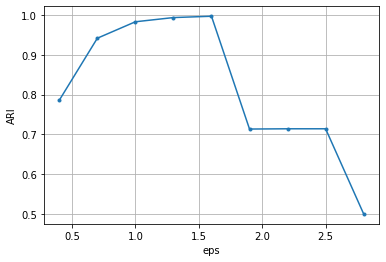

In [9]:
plt.plot(np.arange(0.4, 3, 0.3), ari_list, '.-')
plt.grid()
plt.xlabel('eps')
plt.ylabel('ARI')

ARI trend with respect to different values of $\varepsilon$ confirms that an optimal value for $\varepsilon$ is around 1.5.

# 3.2  Agglomerative clustering

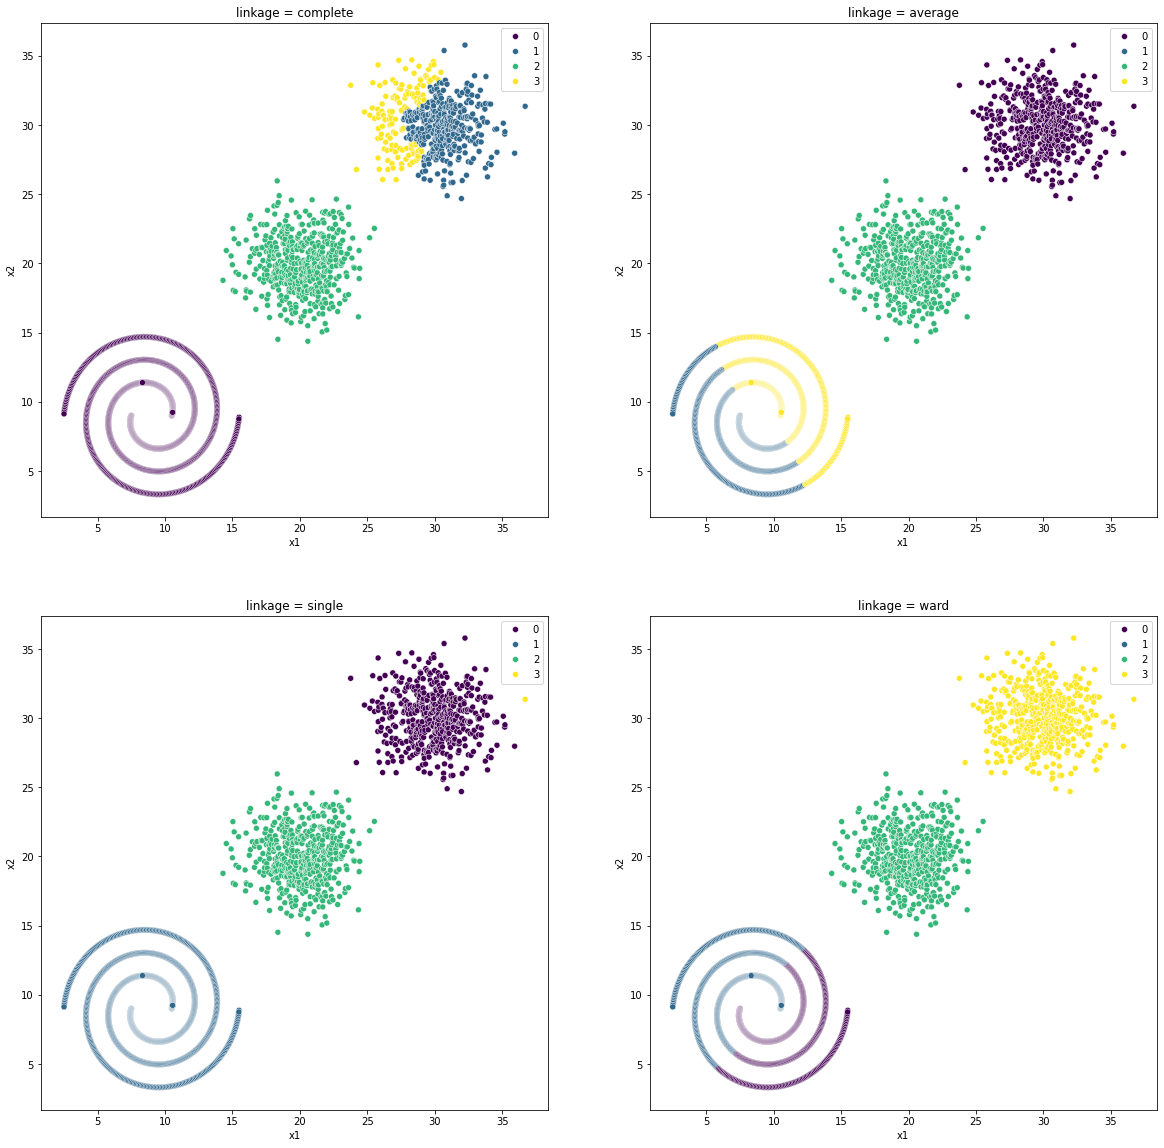

In [10]:
f, axes = plt.subplots(2, 2, figsize = (20, 20))
ari_list = []
for enu, linkage in enumerate(['complete', 'average', 'single','ward']):
    y_pred = AgglomerativeClustering(n_clusters = 4, linkage = linkage).fit_predict(df.drop('class', axis = 1))
    sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = y_pred, palette = 'viridis', ax = axes[enu // 2][enu % 2])
    axes[enu // 2][enu % 2].set_title(f'linkage = {linkage}')
    ari_list.append(adjusted_rand_score(df['class'], y_pred))
    
plt.show()

Single linkage seems to be promising and could enable the identification of the spirals. In fact, it is typically capable of modelling *long chains*.  However, with n_clusters = 4 there is something wrong with the spirals and there is a "single object" cluster . Let's have a look at the dendrogram

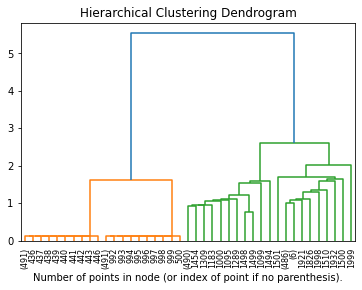

In [11]:
# import numpy as np

from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# function from the docs: https://scikit-learn.org/stable/auto_examples/cluster/plot_agglomerative_dendrogram.html

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold = 0, linkage = 'single', n_clusters = None)

model = model.fit(df.drop('class', axis = 1))
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode = "level", p = 10)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

0.9960033648047578

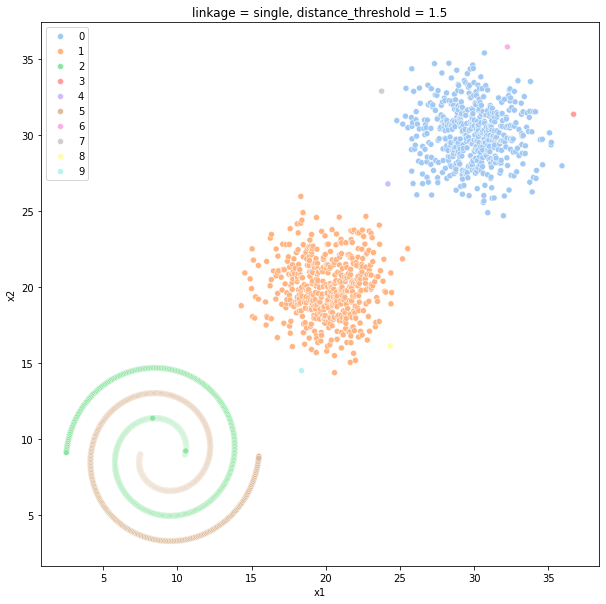

In [12]:
threshold = 1.5
model = AgglomerativeClustering(distance_threshold = threshold, 
                                linkage = 'single', 
                                n_clusters = None)
y_pred = model.fit_predict(df.drop('class', axis = 1))

fig = plt.figure(figsize = (10, 10))

sns.scatterplot(data = df, x = 'x1', y = 'x2', hue = y_pred, palette = 'pastel')
plt.title(f'linkage = single, distance_threshold = {threshold}')

adjusted_rand_score(df['class'], y_pred)

A proper tuning of the distance threshold (around 1.5) allows an almost perfect modelling of the dataset (ARI = 0.996) using Agglomerative clustering with single linkage.